# LAB 3 / THỰC HÀNH: PHÂN TRÃ GIÁ TRỊ KỲ DỊ (SVD) & PHÂN TÍCH THÀNH PHẦN CHÍNH (PCA) TRONG KHÔNG GIAN 2D

## 1. Giới thiệu & Mục tiêu khoa học
Trong bài thực nghiệm này, chúng ta sẽ thực hiện tuần tự các bước:
1. **Khởi tạo dữ liệu ngẫu nhiên:** Tạo $N = 100$ điểm dữ liệu trong không gian 2 chiều ($D = 2$) có tương quan tuyến tính (anisotropic distribution) nhằm thể hiện rõ các hướng phân phối chính.
2. **Tiền xử lý:** Chuẩn hóa tâm dữ liệu (Mean Centering) về trung bình $(0, 0)$.
3. **Triển khai SVD bằng Thư viện (`numpy.linalg.svd`):** Phân rã ma trận dữ liệu $X = U \Sigma V^T$ và tính toán/giải thích chi tiết các ma trận bên trong ($U$, $\Sigma$, $V^T$).
4. **Triển khai thuật toán SVD từ gốc (From-Scratch Implementation):** Tính toán $U, \Sigma, V^T$ thông qua phân rã trị riêng (Eigenvalue Decomposition) của ma trận hiệp phương sai / ma trận Gram $X^T X$ và $X X^T$.
5. **Kiểm chứng sự tái tạo dữ liệu (Reconstruction Verification):** Chứng minh tính chính xác tuyệt đối khi phục hồi lại ma trận $X \approx U \Sigma V^T$.
6. **Mối liên hệ toán học sâu sắc giữa SVD và PCA:** Chứng minh tại sao vector kỳ dị phải ($V$) chính là các hướng thành phần chính (Principal Component Directions) và hình chiếu PCA được tính bằng $Z = X V = U \Sigma$.
7. **Trực quan hóa hình học 2D (`Matplotlib/Seaborn`):** Vẽ biểu đồ phân bố dữ liệu gốc, các vector kỳ dị/thành phần chính và dữ liệu sau hình chiếu PCA.

In [1]:
# Import các thư viện khoa học dữ liệu và trực quan hóa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị Matplotlib
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica']

# Cấu hình in ấn numpy giúp hiển thị ma trận gọn gàng, trực quan
np.set_printoptions(precision=4, suppress=True)

print("✅ Đã import thành công các thư viện khoa học dữ liệu!")

/home/dacekey/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-grewysc1 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


✅ Đã import thành công các thư viện khoa học dữ liệu!


## 2. Khởi tạo Ngẫu nhiên 100 Điểm Dữ liệu trong Không gian 2 Chiều ($N=100, D=2$)

Để SVD và PCA thể hiện rõ các hướng kỳ dị chính (đâu là hướng có phương sai lớn nhất, đâu là hướng phương sai nhỏ nhất), chúng ta không tạo dữ liệu phân bố tròn đều (isotropic uniform), mà khởi tạo **đám mây điểm nhị biến chuẩn có tương quan tuyến tính rõ rệt (Bivariate Normal with Covariance/Rotation)**.

- **Số điểm dữ liệu ($N$):** $100$
- **Số chiều ($D$):** $2$ (Trục $x_1$ và Trục $x_2$)
- **Kỳ vọng ban đầu ($\mu_{\text{true}}$):** $[4.0, 5.0]$
- **Ma trận hiệp phương sai sinh mẫu ($\Sigma_{\text{true}}$):** $\begin{bmatrix} 3.5 & 2.4 \\ 2.4 & 2.2 \end{bmatrix}$ (tạo ra đám mây điểm nghiêng một góc $\approx 35^\circ$)

In [2]:
# Thiết lập random seed để đảm bảo khả năng lặp lại (reproducibility)
np.random.seed(42)

# Tham số tạo mẫu
N = 100
D = 2
mean_vec = np.array([4.0, 5.0])
cov_mat = np.array([[3.5, 2.4],
                    [2.4, 2.2]])

# Tạo N = 100 điểm ngẫu nhiên theo phân phối nhị biến chuẩn
X_raw = np.random.multivariate_normal(mean_vec, cov_mat, size=N)

# Tạo DataFrame để theo dõi dữ liệu ban đầu
df_raw = pd.DataFrame(X_raw, columns=['Feature 1 (x1)', 'Feature 2 (x2)'])

print(f"📐 Kích thước ma trận dữ liệu gốc X_raw: {X_raw.shape}")
print(f"📊 Vector trung bình thực tế của mẫu: {np.mean(X_raw, axis=0)}")
print("\n🔍 5 điểm dữ liệu đầu tiên:")
display(df_raw.head())

📐 Kích thước ma trận dữ liệu gốc X_raw: (100, 2)
📊 Vector trung bình thực tế của mẫu: [4.1995 5.1785]

🔍 5 điểm dữ liệu đầu tiên:


,Feature 1 (x1),Feature 2 (x2)
0,3.139390,4.236496
1,2.253709,4.820045
2,4.515366,5.216596
3,0.821589,3.150544
4,4.662501,5.918856


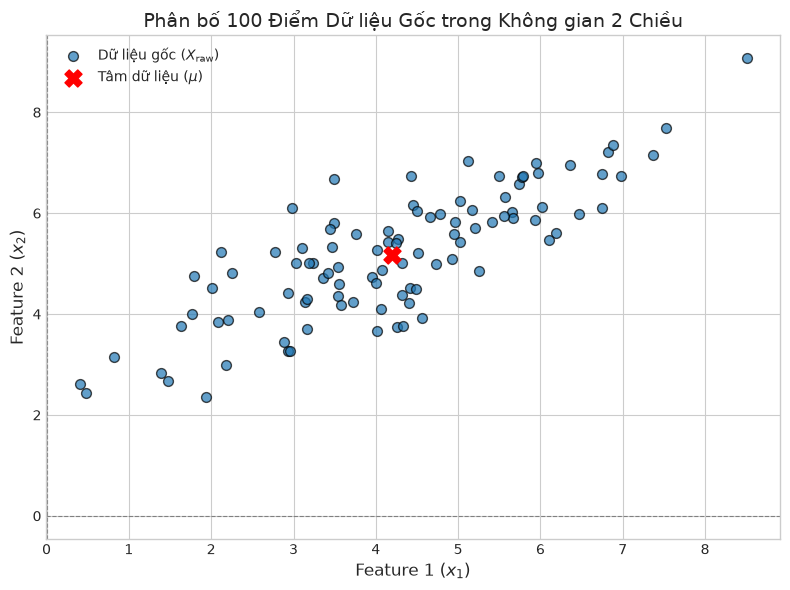

In [3]:
# Trực quan hóa dữ liệu gốc ban đầu
plt.figure(figsize=(8, 6))
plt.scatter(X_raw[:, 0], X_raw[:, 1], c='#1f77b4', alpha=0.7, edgecolors='black', s=50, label=r'Dữ liệu gốc ($X_{\mathrm{raw}}$)')
plt.scatter(np.mean(X_raw[:, 0]), np.mean(X_raw[:, 1]), c='red', marker='X', s=150, label=r'Tâm dữ liệu ($\mu$)')
plt.title("Phân bố 100 Điểm Dữ liệu Gốc trong Không gian 2 Chiều")
plt.xlabel("Feature 1 ($x_1$)")
plt.ylabel("Feature 2 ($x_2$)")
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.legend()
plt.tight_layout()
plt.show()

## 3. Tiền xử lý: Chuẩn hóa Tâm Dữ liệu (Mean Centering)

Trong Phân tích Thành phần chính (PCA) cũng như Phân rã SVD cho mục đích thống kê, bước chuẩn hóa tâm là **bắt buộc**. Nếu không trừ trung bình, thành phần chính đầu tiên ($PC_1$) hoặc vector kỳ dị trái/phải đầu tiên sẽ bị chi phối bởi vị trí của gốc tọa độ $(0, 0)$ hướng tới tâm đám mây điểm, thay vì bắt các hướng phương sai cực đại bên trong nội tại dữ liệu.

$$\mu = \frac{1}{N} \sum_{i=1}^N x_i \quad \in \mathbb{R}^D$$

$$X = X_{\text{raw}} - \mu \quad \in \mathbb{R}^{N \times D}$$

Từ thời điểm này, khi nói đến ma trận dữ liệu $X$, chúng ta ám chỉ **ma trận đã chuẩn hóa tâm ($X_{\text{centered}}$)**.

In [4]:
# Tính vector trung bình của từng đặc trưng (theo cột)
mu = np.mean(X_raw, axis=0)

# Chuẩn hóa tâm: trừ trung bình
X = X_raw - mu

print(f"📊 Vector trung bình sau chuẩn hóa tâm: {np.mean(X, axis=0)} (Xấp xỉ chính xác bằng 0)")
print(f"📐 Kích thước ma trận X chuẩn hóa tâm: {X.shape}")

df_centered = pd.DataFrame(X, columns=['x1_centered', 'x2_centered'])
display(df_centered.head())

📊 Vector trung bình sau chuẩn hóa tâm: [-0. -0.] (Xấp xỉ chính xác bằng 0)
📐 Kích thước ma trận X chuẩn hóa tâm: (100, 2)


,x1_centered,x2_centered
0,-1.060158,-0.942027
1,-1.945839,-0.358478
2,0.315818,0.038073
3,-3.377959,-2.027979
4,0.462953,0.740334


## 4. Triển khai SVD bằng Thư viện (`numpy.linalg.svd`) và Phân tích Các Ma trận Bên trong

Định lý Phân rã Giá trị Kỳ dị (Singular Value Decomposition - SVD) khẳng định rằng bất kỳ ma trận thực $X \in \mathbb{R}^{N \times D}$ nào (ở đây $N=100, D=2$) đều có thể được viết dưới dạng tích của 3 ma trận:

$$X = U \Sigma V^T$$

Trong hàm `np.linalg.svd(X, full_matrices=False)` (Reduced SVD / Compact SVD):
1. **Ma trận $U \in \mathbb{R}^{N \times D}$ ($100 \times 2$):** Ma trận vector kỳ dị trái (Left Singular Vectors). Các cột của $U$ là các vector riêng trực chuẩn (orthonormal eigenvectors) của ma trận Gram $X X^T$. Thỏa mãn $U^T U = I_2$.
2. **Vector / Ma trận $\Sigma \in \mathbb{R}^{D \times D}$ ($2 \times 2$):** Ma trận đường chéo chứa các **Giá trị kỳ dị (Singular Values)** $\sigma_1 \ge \sigma_2 \ge 0$. Hàm `numpy` trả về vector 1D chứa đường chéo $S = [\sigma_1, \sigma_2]$. Thỏa mãn $\sigma_i = \sqrt{\lambda_i(X^T X)}$.
3. **Ma trận $V^T \in \mathbb{R}^{D \times D}$ ($2 \times 2$):** Ma trận vector kỳ dị phải chuyển vị (Right Singular Vectors transposed). Các hàng của $V^T$ (hay cột của $V$) là các vector riêng trực chuẩn của ma trận hiệp phương sai $X^T X$. Thỏa mãn $V^T V = V V^T = I_2$.

In [5]:
# Triển khai SVD dạng thu gọn (compact/reduced SVD: full_matrices=False)
U_lib, S_lib, Vt_lib = np.linalg.svd(X, full_matrices=False)

# Biến vector S thành ma trận đường chéo Sigma (2x2)
Sigma_lib = np.diag(S_lib)

print("="*75)
print("📌 KẾT QUẢ PHÂN RÃ SVD TỪ THƯ VIỆN (`numpy.linalg.svd`)")
print("="*75)
print(f"1️⃣ Ma trận U (Left Singular Vectors): Kích thước {U_lib.shape}")
print("   -> 5 hàng đầu tiên của U:")
print(U_lib[:5, :])
print(f"   -> Kiểm chứng tính trực chuẩn U^T @ U:\n{U_lib.T @ U_lib}\n")

print(f"2️⃣ Vector giá trị kỳ dị S: {S_lib}")
print(f"   -> Ma trận đường chéo Sigma (2x2):\n{Sigma_lib}\n")

print(f"3️⃣ Ma trận V^T (Right Singular Vectors transposed): Kích thước {Vt_lib.shape}")
print(f"   -> Giá trị ma trận V^T:\n{Vt_lib}")
print(f"   -> Ma trận V (các cột là vector kỳ dị phải):\n{Vt_lib.T}")
print(f"   -> Kiểm chứng tính trực chuẩn V^T @ V:\n{Vt_lib.T @ Vt_lib}")
print("="*75)

📌 KẾT QUẢ PHÂN RÃ SVD TỪ THƯ VIỆN (`numpy.linalg.svd`)
1️⃣ Ma trận U (Left Singular Vectors): Kích thước (100, 2)
   -> 5 hàng đầu tiên của U:
[[-0.0718  0.0199]
 [-0.0901 -0.1467]
 [ 0.014   0.0265]
 [-0.1991 -0.0667]
 [ 0.0414 -0.0527]]
   -> Kiểm chứng tính trực chuẩn U^T @ U:
[[ 1. -0.]
 [-0.  1.]]

2️⃣ Vector giá trị kỳ dị S: [19.6834  5.9889]
   -> Ma trận đường chéo Sigma (2x2):
[[19.6834  0.    ]
 [ 0.      5.9889]]

3️⃣ Ma trận V^T (Right Singular Vectors transposed): Kích thước (2, 2)
   -> Giá trị ma trận V^T:
[[ 0.8007  0.599 ]
 [ 0.599  -0.8007]]
   -> Ma trận V (các cột là vector kỳ dị phải):
[[ 0.8007  0.599 ]
 [ 0.599  -0.8007]]
   -> Kiểm chứng tính trực chuẩn V^T @ V:
[[ 1. -0.]
 [-0.  1.]]


## 5. Triển khai Thuật toán SVD Từ gốc (From-Scratch Implementation)

Để hiểu sâu sắc bản chất toán học của SVD thay vì coi nó như một "hộp đen thư viện", chúng ta sẽ tự xây dựng hàm SVD dựa trên **Phân rã Trị riêng (Eigenvalue Decomposition)** của ma trận đối xứng $A = X^T X \in \mathbb{R}^{D \times D}$ ($2 \times 2$).

### Các bước thuật toán:
1. **Tính ma trận đối xứng $A = X^T X$ ($2 \times 2$).**
2. **Phân rã trị riêng của $A$:** Tìm các trị riêng $\lambda_i$ và vector riêng $v_i$ sao cho $A v_i = \lambda_i v_i$.
3. **Sắp xếp giảm dần theo trị riêng:** $\lambda_1 \ge \lambda_2 \ge 0$ và sắp xếp tương ứng các vector riêng cột trong ma trận $V = [v_1, v_2]$.
4. **Tính các giá trị kỳ dị $\sigma_i$:** $\sigma_i = \sqrt{\lambda_i}$.
5. **Tính ma trận vector kỳ dị trái $U$:** Với mỗi thành phần $i \in \{1, 2\}$, ta có:
   $$u_i = \frac{1}{\sigma_i} X v_i \quad \Rightarrow \quad U = X V \Sigma^{-1}$$

*Lưu ý về dấu vector riêng (Eigenvector Sign Ambiguity):* Khi nhân một vector riêng với $-1$, nó vẫn là vector riêng đúng hợp lệ của hệ $A v = \lambda v$. Do đó, $U_{\text{scratch}}$ và $V_{\text{scratch}}$ có thể bị lật dấu đồng thời trên cả 2 vector (ví dụ cột $u_1$ đổi thành $-u_1$ và cột $v_1$ đổi thành $-v_1$) mà tích $U \Sigma V^T$ hoàn toàn không thay đổi!

In [6]:
def svd_from_scratch(X_in):
    """
    Hàm tự triển khai SVD (Reduced SVD) cho ma trận X_in (N x D) từ gốc
    thông qua phân rã trị riêng của ma trận Gram X^T X.
    """
    N, D = X_in.shape
    
    # Bước 1: Tính ma trận Gram A = X^T * X (Kích thước D x D = 2 x 2)
    A = X_in.T @ X_in
    
    # Bước 2: Phân rã trị riêng của ma trận đối xứng A
    # np.linalg.eigh được thiết kế chuyên biệt cho ma trận Hermite/đối xứng real
    eigenvalues, eigenvectors = np.linalg.eigh(A)
    
    # Bước 3: Sắp xếp giảm dần theo trị riêng
    sort_idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[sort_idx]
    V_scratch = eigenvectors[:, sort_idx]  # Các cột của V là vector riêng của X^T * X
    
    # Bước 4: Tính vector giá trị kỳ dị Sigma = sqrt(eigenvalues)
    # Dùng np.maximum để tránh lỗi số học số âm vi mô (ví dụ -1e-16)
    S_scratch = np.sqrt(np.maximum(eigenvalues, 0.0))
    Sigma_scratch = np.diag(S_scratch)
    
    # Bước 5: Tính ma trận vector kỳ dị trái U = X * V * Sigma^(-1)
    U_scratch = np.zeros((N, D))
    for i in range(D):
        if S_scratch[i] > 1e-12:
            U_scratch[:, i] = (X_in @ V_scratch[:, i]) / S_scratch[i]
        else:
            U_scratch[:, i] = np.zeros(N)
            
    Vt_scratch = V_scratch.T
    return U_scratch, S_scratch, Vt_scratch

# Thực thi SVD từ gốc
U_scr, S_scr, Vt_scr = svd_from_scratch(X)

print("="*75)
print("🛠️ KẾT QUẢ TRIỂN KHAI SVD TỪ GỐC (FROM SCRATCH)")
print("="*75)
print(f"1️⃣ Vector giá trị kỳ dị S (From Scratch): {S_scr}")
print(f"   -> So sánh với Thư viện S_lib:            {S_lib}")
print(f"   -> Sai lệch tối đa giữa 2 cách tính:        {np.max(np.abs(S_scr - S_lib)):.2e}\n")

print(f"2️⃣ Ma trận V^T (From Scratch):\n{Vt_scr}")
print(f"   -> Ma trận V^T (Thư viện):\n{Vt_lib}")
# Kiểm tra sự trùng khớp (có thể sai lệch dấu +/- trên từng hàng của V^T tương ứng với cột của U)
sign_diff_Vt = np.allclose(np.abs(Vt_scr), np.abs(Vt_lib))
print(f"   -> Các hướng vector kỳ dị phải trùng khớp (bỏ qua lật dấu): {sign_diff_Vt}\n")

print(f"3️⃣ Ma trận U (From Scratch) - 5 hàng đầu:\n{U_scr[:5, :]}")
print(f"   -> Ma trận U (Thư viện) - 5 hàng đầu:\n{U_lib[:5, :]}")
sign_diff_U = np.allclose(np.abs(U_scr), np.abs(U_lib))
print(f"   -> Các vector kỳ dị trái trùng khớp (bỏ qua lật dấu): {sign_diff_U}")
print("="*75)

🛠️ KẾT QUẢ TRIỂN KHAI SVD TỪ GỐC (FROM SCRATCH)
1️⃣ Vector giá trị kỳ dị S (From Scratch): [19.6834  5.9889]
   -> So sánh với Thư viện S_lib:            [19.6834  5.9889]
   -> Sai lệch tối đa giữa 2 cách tính:        7.11e-15

2️⃣ Ma trận V^T (From Scratch):
[[-0.8007 -0.599 ]
 [ 0.599  -0.8007]]
   -> Ma trận V^T (Thư viện):
[[ 0.8007  0.599 ]
 [ 0.599  -0.8007]]
   -> Các hướng vector kỳ dị phải trùng khớp (bỏ qua lật dấu): True

3️⃣ Ma trận U (From Scratch) - 5 hàng đầu:
[[ 0.0718  0.0199]
 [ 0.0901 -0.1467]
 [-0.014   0.0265]
 [ 0.1991 -0.0667]
 [-0.0414 -0.0527]]
   -> Ma trận U (Thư viện) - 5 hàng đầu:
[[-0.0718  0.0199]
 [-0.0901 -0.1467]
 [ 0.014   0.0265]
 [-0.1991 -0.0667]
 [ 0.0414 -0.0527]]
   -> Các vector kỳ dị trái trùng khớp (bỏ qua lật dấu): True


## 6. Kiểm chứng Sự Tái tạo Dữ liệu (Reconstruction Verification)

Một trong những tính chất quan trọng nhất của SVD là tính hoàn thiện (Completeness): Khi nhân ngược lại 3 ma trận $U \Sigma V^T$, ta phải thu được chính xác ma trận ban đầu $X$ (sai số chỉ do giới hạn biểu diễn số thực dấu phẩy động Float64 của máy tính $\approx 10^{-15}$).

$$X_{\text{reconstructed}} = U \Sigma V^T$$

Nếu cộng thêm vector trung bình $\mu$, ta khôi phục trọn vẹn dữ liệu gốc trước khi chuẩn hóa tâm:

$$X_{\text{raw\_reconstructed}} = U \Sigma V^T + \mu$$

In [7]:
# Tái tạo lại ma trận X_centered từ U, Sigma, Vt của thư viện
X_reconstructed_lib = U_lib @ np.diag(S_lib) @ Vt_lib

# Tái tạo lại từ SVD tự triển khai (from scratch)
X_reconstructed_scr = U_scr @ np.diag(S_scr) @ Vt_scr

# Tái tạo về dữ liệu gốc X_raw
X_raw_reconstructed = X_reconstructed_lib + mu

# Kiểm chứng sai số Frobenius / Max Absolute Error
err_lib = np.max(np.abs(X - X_reconstructed_lib))
err_scr = np.max(np.abs(X - X_reconstructed_scr))
err_raw = np.max(np.abs(X_raw - X_raw_reconstructed))

print("="*75)
print("🔍 KIỂM CHỨNG TÁI TẠO MA TRẬN DỮ LIỆU GỐC (RECONSTRUCTION ERROR)")
print("="*75)
print(f"✅ Sai số tối đa |X - U * Sigma * Vt| (Thư viện):      {err_lib:.2e}")
print(f"✅ Sai số tối đa |X - U * Sigma * Vt| (From Scratch):  {err_scr:.2e}")
print(f"✅ Sai số tối đa |X_raw - (U * Sigma * Vt + mu)|:      {err_raw:.2e}")
print("="*75)
print("\n👉 Bảng đối chiếu 5 điểm đầu tiên (Dữ liệu thực vs Dữ liệu tái tạo):")
df_comp = pd.DataFrame({
    'x1_centered (Thực)': X[:5, 0],
    'x1_reconstructed': X_reconstructed_lib[:5, 0],
    'x2_centered (Thực)': X[:5, 1],
    'x2_reconstructed': X_reconstructed_lib[:5, 1]
})
display(df_comp)

🔍 KIỂM CHỨNG TÁI TẠO MA TRẬN DỮ LIỆU GỐC (RECONSTRUCTION ERROR)
✅ Sai số tối đa |X - U * Sigma * Vt| (Thư viện):      1.78e-15
✅ Sai số tối đa |X - U * Sigma * Vt| (From Scratch):  8.88e-16
✅ Sai số tối đa |X_raw - (U * Sigma * Vt + mu)|:      1.78e-15

👉 Bảng đối chiếu 5 điểm đầu tiên (Dữ liệu thực vs Dữ liệu tái tạo):


,x1_centered (Thực),x1_reconstructed,x2_centered (Thực),x2_reconstructed
0,-1.060158,-1.060158,-0.942027,-0.942027
1,-1.945839,-1.945839,-0.358478,-0.358478
2,0.315818,0.315818,0.038073,0.038073
3,-3.377959,-3.377959,-2.027979,-2.027979
4,0.462953,0.462953,0.740334,0.740334


## 7. Mối liên hệ Toán học Sâu sắc giữa SVD và Phân tích Thành phần chính (PCA)

Trong thực tế ứng dụng học máy và khoa học dữ liệu (chẳng hạn như trong các thư viện `scikit-learn`), **PCA không bao giờ được tính bằng cách lập ma trận hiệp phương sai rồi giải `np.linalg.eig(cov)` trực tiếp**. Nguyên nhân là tính toán $X^T X$ cho ma trận lớn có thể gây thảm họa mất độ chính xác số học (condition number bị bình phương). Thay vào đó, **PCA luôn được giải trực tiếp thông qua SVD của ma trận chuẩn hóa tâm $X$**!

### Chứng minh toán học:
Ma trận hiệp phương sai mẫu của $X$ (đã chuẩn hóa tâm) được định nghĩa là:
$$C = \frac{1}{N-1} X^T X \quad \in \mathbb{R}^{D \times D}$$

Thay thế $X = U \Sigma V^T$ vào công thức của $C$:
$$C = \frac{1}{N-1} (U \Sigma V^T)^T (U \Sigma V^T) = \frac{1}{N-1} V \Sigma^T (U^T U) \Sigma V^T$$

Vì $U$ là trực chuẩn ($U^T U = I$), và $\Sigma$ là ma trận đường chéo ($\Sigma^T = \Sigma$), ta có:
$$C = V \left( \frac{\Sigma^2}{N-1} \right) V^T$$

Đây chính là dạng Phân rã Trị riêng của ma trận hiệp phương sai $C = V \Lambda V^T$!
Từ đó rút ra 3 kết luận vô giá:
1. **Các hướng thành phần chính (PCA Principal Component Directions / Loadings)** chính là các vector cột của ma trận **$V$** (vector kỳ dị phải).
2. **Trị riêng của ma trận hiệp phương sai ($\lambda_i$)** liên hệ trực tiếp với giá trị kỳ dị ($\sigma_i$) theo công thức:
   $$\lambda_i = \frac{\sigma_i^2}{N-1} \quad \Leftrightarrow \quad \text{Phương sai thành phần chính } PC_i = \frac{\sigma_i^2}{N-1}$$
3. **Ma trận hình chiếu PCA ($Z$) - Tọa độ của các điểm trong không gian thành phần chính mới:**
   $$Z = X V = (U \Sigma V^T) V = U \Sigma (V^T V) = U \Sigma$$
   Vậy hình chiếu PCA có thể tính siêu nhanh ngay từ SVD bằng công thức **$Z = U \Sigma$** mà không cần qua bước nhân $X V$!

In [8]:
# 1. Tính ma trận hiệp phương sai thực tế
C_cov = np.cov(X, rowvar=False) # rowvar=False vì hàng là mẫu, cột là đặc trưng

# 2. Tính trị riêng từ SVD
eigenvalues_from_svd = (S_lib ** 2) / (N - 1)

# 3. Tính ma trận hiệp phương sai tái tạo từ SVD V * Lambda * V^T
C_from_svd = Vt_lib.T @ np.diag(eigenvalues_from_svd) @ Vt_lib

print("="*75)
print("💡 KIỂM CHỨNG MỐI LIÊN HỆ PCA <-> SVD")
print("="*75)
print(f"1️⃣ Trị riêng từ cov matrix (`np.linalg.eigvals`): {np.sort(np.linalg.eigvals(C_cov))[::-1]}")
print(f"   Trị riêng tính từ SVD (`S^2 / (N-1)`):          {eigenvalues_from_svd}\n")

print(f"2️⃣ Ma trận Covariance C (thực tế np.cov):\n{C_cov}\n")
print(f"   Ma trận Covariance tái tạo từ SVD (`V * (S^2/(N-1)) * V^T`):\n{C_from_svd}\n")
print(f"   -> Hai ma trận Covariance trùng khớp hoàn toàn: {np.allclose(C_cov, C_from_svd)}\n")

# 4. Tỷ lệ phương sai giải thích (Explained Variance Ratio)
explained_variance_ratio = eigenvalues_from_svd / np.sum(eigenvalues_from_svd)
print(f"3️⃣ Tỷ lệ phương sai giải thích của PC1: {explained_variance_ratio[0]*100:.2f}%")
print(f"   Tỷ lệ phương sai giải thích của PC2: {explained_variance_ratio[1]*100:.2f}%")
print(f"   -> Tổng phương sai giải thích:         {np.sum(explained_variance_ratio)*100:.2f}%\n")

# 5. Hình chiếu PCA (Principal Component Scores / Projections Z)
Z_via_dot = X @ Vt_lib.T       # Cách 1: Z = X * V
Z_via_US = U_lib @ Sigma_lib   # Cách 2: Z = U * Sigma

print(f"4️⃣ Kiểm tra sự trùng khớp của hình chiếu Z giữa `X * V` và `U * Sigma`: {np.allclose(Z_via_dot, Z_via_US)}")
print("   -> 5 điểm đầu tiên trong không gian thành phần chính mới Z:")
df_pca = pd.DataFrame(Z_via_US[:5, :], columns=['PC1 (Thành phần chính 1)', 'PC2 (Thành phần chính 2)'])
display(df_pca)
print("="*75)

💡 KIỂM CHỨNG MỐI LIÊN HỆ PCA <-> SVD
1️⃣ Trị riêng từ cov matrix (`np.linalg.eigvals`): [3.9135 0.3623]
   Trị riêng tính từ SVD (`S^2 / (N-1)`):          [3.9135 0.3623]

2️⃣ Ma trận Covariance C (thực tế np.cov):
[[2.6391 1.7034]
 [1.7034 1.6367]]

   Ma trận Covariance tái tạo từ SVD (`V * (S^2/(N-1)) * V^T`):
[[2.6391 1.7034]
 [1.7034 1.6367]]

   -> Hai ma trận Covariance trùng khớp hoàn toàn: True

3️⃣ Tỷ lệ phương sai giải thích của PC1: 91.53%
   Tỷ lệ phương sai giải thích của PC2: 8.47%
   -> Tổng phương sai giải thích:         100.00%

4️⃣ Kiểm tra sự trùng khớp của hình chiếu Z giữa `X * V` và `U * Sigma`: True
   -> 5 điểm đầu tiên trong không gian thành phần chính mới Z:


,PC1 (Thành phần chính 1),PC2 (Thành phần chính 2)
0,-1.413202,0.119210
1,-1.772806,-0.878610
2,0.275687,0.158704
3,-3.919633,-0.399723
4,0.814187,-0.315465


## 8. Trực quan hóa Hình học Toàn diện (Matplotlib Visualization)

Để cảm nhận rõ nhất vẻ đẹp hình học của SVD và PCA trong không gian 2D, chúng ta sẽ vẽ lưới biểu đồ 2x2 thể hiện 4 góc nhìn:
- **Biểu đồ 1 (Top-Left):** 100 điểm dữ liệu gốc $X_{\text{raw}}$ cùng tâm trung bình $\mu$.
- **Biểu đồ 2 (Top-Right):** 100 điểm dữ liệu đã chuẩn hóa tâm $X_{\text{centered}}$ cùng 2 vector thành phần chính (Trục kỳ dị phải $v_1, v_2$) có độ dài tỷ lệ với độ lệch chuẩn $\sigma_i / \sqrt{N-1}$ (hoặc giá trị kỳ dị).
- **Biểu đồ 3 (Bottom-Left):** Phân bố 100 điểm trong không gian thành phần chính ($PC_1 - PC_2$). Lúc này đám mây điểm đã được xoay thẳng trục ngang dọc dọc theo trục có phương sai lớn nhất!
- **Biểu đồ 4 (Bottom-Right):** Minh họa sự giảm rèn/nén dữ liệu (Rank-1 Approximation). Phục hồi lại dữ liệu 2D nếu chúng ta chỉ giữ lại thành phần chính đầu tiên ($PC_1$, tức $\sigma_1 u_1 v_1^T$), các điểm rơi thẳng hàng trên 1 đường thẳng duy nhất.

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\S'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\S'
<>:77: SyntaxWarning: invalid escape sequence '\s'
<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:42: SyntaxWarning: invalid escape sequence '\S'
<>:43: SyntaxWarning: invalid escape sequence '\m'
<>:44: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\S'
<>:77: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_30/892321930.py:9: SyntaxWarning: invalid escape sequence '\m'
  ax1.scatter(mu[0], mu[1], c='red', marker='X', s=160, label=f'Tâm $\mu$ = ({mu[0]:.2f}, {mu[1]:.2f})')
/tmp/ipykernel_30/892321930.py:10: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title("1. Dữ liệ

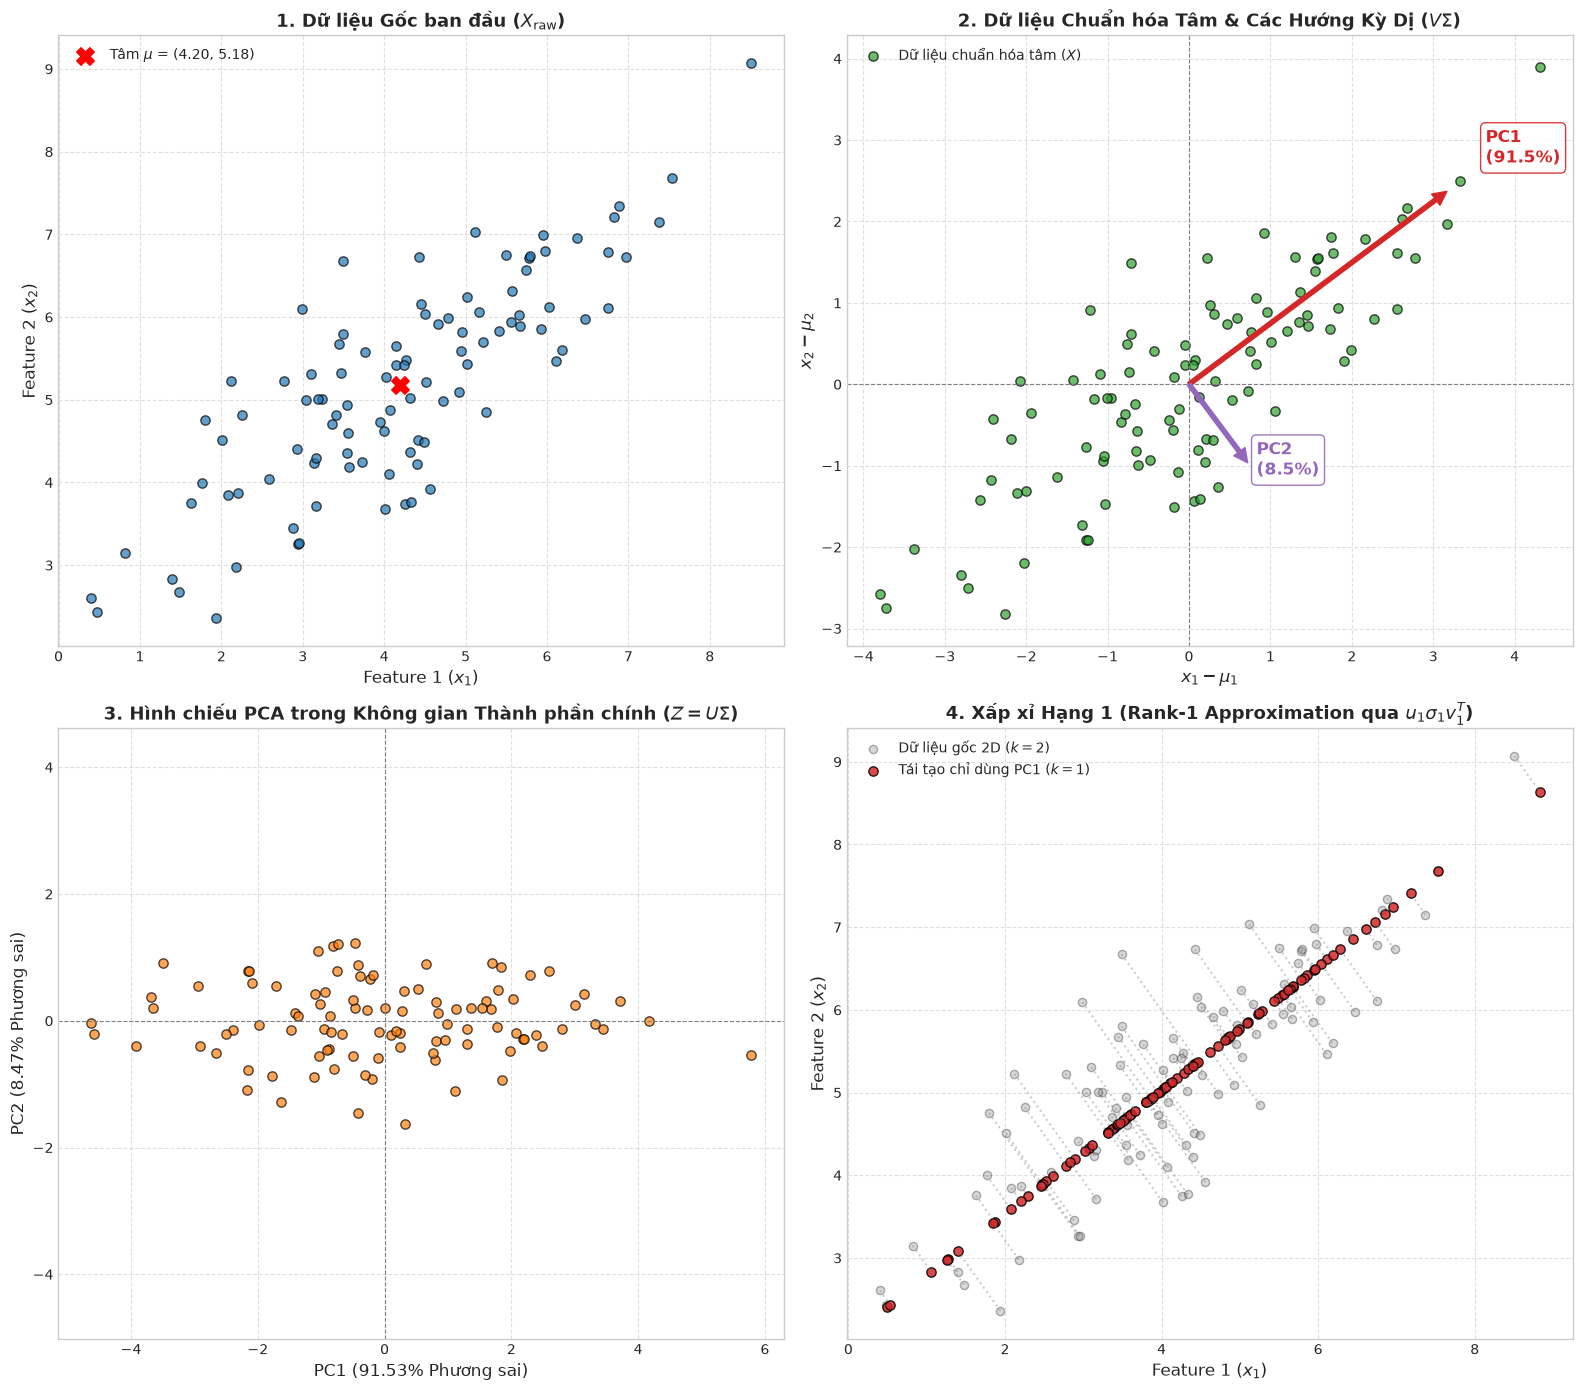

🏁 Đã hoàn thành trực quan hóa và lưu biểu đồ ra file `svd_pca_2d_visualization.png`!


In [9]:
# Thiết lập lưới biểu đồ 2x2
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# -------------------------------------------------------------
# Biểu đồ 1: Dữ liệu gốc
# -------------------------------------------------------------
ax1 = axes[0, 0]
ax1.scatter(X_raw[:, 0], X_raw[:, 1], c='#1f77b4', alpha=0.7, edgecolors='k', s=45)
ax1.scatter(mu[0], mu[1], c='red', marker='X', s=160, label=f'Tâm $\mu$ = ({mu[0]:.2f}, {mu[1]:.2f})')
ax1.set_title("1. Dữ liệu Gốc ban đầu ($X_{\mathrm{raw}}$)", fontsize=13, fontweight='bold')
ax1.set_xlabel("Feature 1 ($x_1$)")
ax1.set_ylabel("Feature 2 ($x_2$)")
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------
# Biểu đồ 2: Dữ liệu chuẩn hóa tâm & Các Vector Thành phần chính (Loadings V)
# -------------------------------------------------------------
ax2 = axes[0, 1]
ax2.scatter(X[:, 0], X[:, 1], c='#2ca02c', alpha=0.7, edgecolors='k', s=45, label='Dữ liệu chuẩn hóa tâm ($X$)')

# Vẽ các vector thành phần chính v1 và v2 từ gốc (0,0)
# Độ dài mũi tên tỷ lệ với 1.5 * độ lệch chuẩn (sqrt(variance) = S / sqrt(N-1))
std_devs = S_lib / np.sqrt(N - 1)
scale_factor = 2.0
colors_pc = ['#d62728', '#9467bd'] # Đỏ cho PC1, Tím cho PC2

for i in range(D):
    # Vector hướng là cột thứ i của V (hay hàng thứ i của Vt)
    vec = Vt_lib[i, :] * std_devs[i] * scale_factor
    ax2.annotate('', xy=vec, xytext=(0, 0),
                 arrowprops=dict(facecolor=colors_pc[i], edgecolor=colors_pc[i], 
                                 width=3, headwidth=10, headlength=10))
    # Ghi nhãn cho vector
    ax2.text(vec[0]*1.15, vec[1]*1.15, 
             f'PC{i+1}\n({explained_variance_ratio[i]*100:.1f}%)', 
             color=colors_pc[i], fontsize=12, fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=colors_pc[i], alpha=0.9))

ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax2.set_title("2. Dữ liệu Chuẩn hóa Tâm & Các Hướng Kỳ Dị ($V \Sigma$)", fontsize=13, fontweight='bold')
ax2.set_xlabel("$x_1 - \mu_1$")
ax2.set_ylabel("$x_2 - \mu_2$")
ax2.axis('equal') # Giữ đúng tỷ lệ khung hình để góc trực giao PC1 vuông góc PC2 hiển thị chuẩn
ax2.legend(loc='upper left')
ax2.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------
# Biểu đồ 3: Hình chiếu trong Không gian Thành phần chính PCA (Z = X * V)
# -------------------------------------------------------------
ax3 = axes[1, 0]
ax3.scatter(Z_via_US[:, 0], Z_via_US[:, 1], c='#ff7f0e', alpha=0.7, edgecolors='k', s=45)
ax3.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax3.axvline(0, color='gray', linestyle='--', linewidth=0.8)
ax3.set_title("3. Hình chiếu PCA trong Không gian Thành phần chính ($Z = U \Sigma$)", fontsize=13, fontweight='bold')
ax3.set_xlabel(f"PC1 ({explained_variance_ratio[0]*100:.2f}% Phương sai)")
ax3.set_ylabel(f"PC2 ({explained_variance_ratio[1]*100:.2f}% Phương sai)")
ax3.axis('equal')
ax3.grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------------------
# Biểu đồ 4: Phục hồi Dữ liệu Rank-1 Approximation (Chỉ giữ lại PC1)
# -------------------------------------------------------------
# X_rank1 = u_1 * sigma_1 * v_1^T
X_rank1 = np.outer(U_lib[:, 0], Vt_lib[0, :]) * S_lib[0] + mu

ax4 = axes[1, 1]
# Vẽ điểm gốc mờ
ax4.scatter(X_raw[:, 0], X_raw[:, 1], c='gray', alpha=0.3, edgecolors='k', s=35, label='Dữ liệu gốc 2D ($k=2$)')
# Vẽ điểm xấp xỉ Rank-1
ax4.scatter(X_rank1[:, 0], X_rank1[:, 1], c='#d62728', alpha=0.85, edgecolors='k', s=45, label='Tái tạo chỉ dùng PC1 ($k=1$)')
# Vẽ đường thẳng nối từ điểm gốc đến điểm chiếu rank-1
for i in range(N):
    ax4.plot([X_raw[i, 0], X_rank1[i, 0]], [X_raw[i, 1], X_rank1[i, 1]], color='gray', linestyle=':', alpha=0.4)

ax4.set_title("4. Xấp xỉ Hạng 1 (Rank-1 Approximation qua $u_1 \sigma_1 v_1^T$)", fontsize=13, fontweight='bold')
ax4.set_xlabel("Feature 1 ($x_1$)")
ax4.set_ylabel("Feature 2 ($x_2$)")
ax4.legend()
ax4.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig('svd_pca_2d_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("🏁 Đã hoàn thành trực quan hóa và lưu biểu đồ ra file `svd_pca_2d_visualization.png`!")

## 9. Tổng kết & Kết luận Khoa học (Key Takeaways)

Qua bài thực hành Khởi tạo 100 điểm dữ liệu 2D và Phân rã SVD/PCA, chúng ta đã kiểm chứng các sự thật toán học cốt lõi sau:

1. **SVD là công cụ nền tảng của PCA:** Bất kỳ ma trận dữ liệu $X \in \mathbb{R}^{N \times D}$ đã chuẩn hóa tâm nào đều có phân rã $X = U \Sigma V^T$.
2. ** Ý nghĩa hình học của 3 ma trận:**
   - **$V \in \mathbb{R}^{D \times D}$:** Ma trận trực chuẩn các vector hướng kỳ dị phải. Đây chính là **các hệ trục tọa độ mới của PCA (Principal Component Directions)**. Hàng đầu tiên của $V^T$ chỉ hướng có độ phân tán/phương sai lớn nhất của đám mây điểm.
   - **$\Sigma \in \mathbb{R}^{D \times D}$:** Ma trận đường chéo chứa giá trị kỳ dị $\sigma_i$. Bình phương của nó chia cho $(N-1)$ chính là **trị riêng của ma trận hiệp phương sai ($\sigma_i^2 / (N-1) = \lambda_i$)**, đại diện cho lượng phương sai dữ liệu mà thành phần đó giữ được.
   - **$U \in \mathbb{R}^{N \times D}$:** Ma trận trực chuẩn các vector kỳ dị trái. Tích $U \Sigma = X V = Z$ chính là **tọa độ hình chiếu của $N$ mẫu dữ liệu trong không gian thành phần chính PCA mới**.
3. **Hiệu năng & Tính ổn định số học:** Tính PCA thông qua SVD (`np.linalg.svd(X)`) ổn định và chính xác hơn nhiều so với việc lập ma trận hiệp phương sai rồi giải trị riêng (`np.linalg.eigh(X.T @ X)`), đặc biệt khi số chiều $D$ lớn hoặc ma trận bị suy biến (ill-conditioned).
4. **Ứng dụng Giảm chiều (Dimensionality Reduction & Compression):** Kỹ thuật xấp xỉ hạng $k$ ($X \approx U_k \Sigma_k V_k^T$) cho phép loại bỏ các chiều có giá trị kỳ dị nhỏ (nhiễu), giữ lại các cấu trúc hình học chủ đạo. Đây chính là nguyên lý toán học đằng sau bước nén đặc trưng **PCA $D=571$ từ 1,812 chiều** trong bài toán nhận diện biển báo giao thông NVTS (`@paper`) của chúng ta!